In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import h5py
import helper_functions as hf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
variables = ["mjj","truth_label"]
mjj = hf.loadData("BKG",variables,dEta_cut=-1,sideband=True,mode="all")

100%|██████████| 80/80 [01:37<00:00,  1.22s/it]


In [19]:
lab = mjj[:,1]
mjj = mjj[:,0]

In [20]:
ttbar = mjj[lab==-2]
qcd = mjj[lab==0]
stop = mjj[lab==-1]
vjet = mjj[lab==-3]

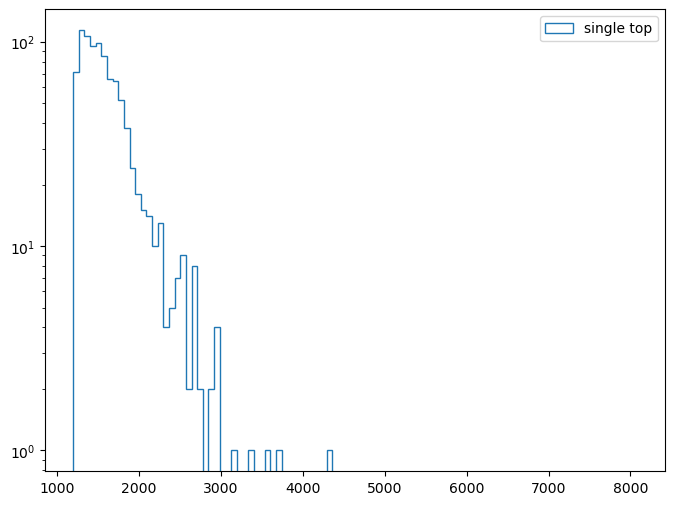

In [23]:
plt.figure(figsize=(8,6))
#h,bins,_ = plt.hist(qcd,histtype='step',density=True,bins=100,label='qcd')
h,bins,_ = plt.hist(stop,histtype='step',density=False,bins=bins,label='single top')
#h,bins,_ = plt.hist(ttbar,histtype='step',density=False,bins=bins,label='ttbar')
#h,bins,_ = plt.hist(vjet,histtype='step',density=True,bins=bins,label="V+jets")
plt.legend()
plt.yscale('log')

# add truth labels to loss files

In [3]:
bkg_file = "BKG.h5"
bkg_SB_file = "BKG_SB.h5"
dirs = ["lossEvals","lossEvals_pcaDecorr","lossEvals_pcaDecorr_boxCox",
        "lossEvals_linearDecorr","lossEvals_linearDecorr_boxCox","lossEvals_noDecorr"]
variables = ["mjj","truth_label"]
data = hf.loadData("BKG",variables,dEta_cut=1.3,sideband=False,mode="all")
data_SB = hf.loadData("BKG",variables,dEta_cut=-1,sideband=True,mode="all")

100%|██████████| 80/80 [00:40<00:00,  1.96it/s]


In [4]:
with h5py.File(f"{dirs[0]}/{bkg_file}","r") as f:
    mjj = f["mjj"][()]
with h5py.File(f"{dirs[0]}/{bkg_SB_file}","r") as f:
    mjj_SB = f["mjj"][()]

In [5]:
print(data.shape)
print(mjj.shape)
print(np.all(data[:,0]==mjj))
print(data_SB.shape)
print(mjj_SB.shape)
print(np.all(data_SB[:,0]==mjj_SB))

(7440870, 2)
(7440870,)
True
(2601768, 2)
(2601768,)
True


In [6]:
from tqdm import tqdm
files = [f"{d}/{bkg_file}" for d in dirs]
files_SB = [f"{d}/{bkg_SB_file}" for d in dirs]
for f in files:
    with h5py.File(f,"r+") as fout:
        fout.create_dataset("truth_label",data=data[:,1])
for f in files_SB:
    with h5py.File(f,"r+") as fout:
        fout.create_dataset("truth_label",data=data_SB[:,1])

In [32]:
with h5py.File(f"{dirs[0]}/{bkg_file}","r") as f:
    mjj = f["mjj"][()]
    tl = f["truth_label"][()]
with h5py.File(f"{dirs[0]}/{bkg_SB_file}","r") as f:
    mjj_SB = f["mjj"][()]
    tl_SB = f["truth_label"][()]